In [1]:
# CELL 1 — Install Libraries
!pip install pandas numpy scikit-learn matplotlib seaborn joblib tensorflow --quiet
print(' All libraries installed!')

 All libraries installed!


In [2]:

# CELL 2 — Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, joblib, os, json, time

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(' All imports successful!')
print(f'   TensorFlow : {tf.__version__}')

 All imports successful!
   TensorFlow : 2.19.0


In [3]:

# CELL 3 — Upload Dataset Files

from google.colab import files

print(' Upload db_building_A.csv and db_building_B.csv ')
uploaded = files.upload()
print(f'\n Uploaded files: {list(uploaded.keys())}')

 Upload db_building_A.csv and db_building_B.csv 


Saving db_building_B.csv to db_building_B.csv
Saving db_building_A.csv to db_building_A.csv

 Uploaded files: ['db_building_B.csv', 'db_building_A.csv']


In [4]:

# CELL 4 — Load & Merge Both Buildings

def load_building(fname, building_id):
    df = pd.read_csv(fname, parse_dates=['DATE'])
    df['building'] = building_id
    return df

df_A = load_building('db_building_A.csv', 'A')
df_B = load_building('db_building_B.csv', 'B')

common_cols = ['DATE','ENERGY','HDD18_3','CDD0','CDD10',
               'PRECTOT','RH2M','T2M','T2M_MIN','T2M_MAX',
               'ALLSKY','HOLIDAY','building']
df_A = df_A.reindex(columns=common_cols)
df_B = df_B.reindex(columns=common_cols)

df_raw = pd.concat([df_A, df_B], ignore_index=True)

print(f' Building A : {len(df_A):,} rows')
print(f' Building B : {len(df_B):,} rows')
print(f' Combined  : {df_raw.shape}')
display(df_raw.head())

 Building A : 43,848 rows
 Building B : 43,848 rows
 Combined  : (87696, 13)


,DATE,ENERGY,HDD18_3,CDD0,CDD10,PRECTOT,RH2M,T2M,T2M_MIN,T2M_MAX,ALLSKY,HOLIDAY,building
0,2016-01-01 00:00:00,NaN,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
1,2016-01-01 01:00:00,113.415,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
2,2016-01-01 02:00:00,112.431,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
3,2016-01-01 03:00:00,111.517,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
4,2016-01-01 04:00:00,117.240,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A


In [5]:

# CELL 5 — Clean Data

print('Before cleaning — nulls:')
print(df_raw.isnull().sum())

df_raw.dropna(subset=['ENERGY'], inplace=True)
df_raw['ALLSKY'].fillna(df_raw['ALLSKY'].median(), inplace=True)

print(f'\n After cleaning — Shape: {df_raw.shape}')
print('Remaining nulls:', df_raw.isnull().sum().sum())

Before cleaning — nulls:
DATE          0
ENERGY      169
HDD18_3       0
CDD0          0
CDD10         0
PRECTOT       0
RH2M          0
T2M           0
T2M_MIN       0
T2M_MAX       0
ALLSKY      288
HOLIDAY       0
building      0
dtype: int64

 After cleaning — Shape: (87527, 13)
Remaining nulls: 0


In [6]:

# CELL 6 — Feature Engineering

df = df_raw.copy()

df['hour']       = df['DATE'].dt.hour
df['dayofweek']  = df['DATE'].dt.dayofweek
df['month']      = df['DATE'].dt.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['building_enc'] = (df['building'] == 'B').astype(int)
df['T2M_range']    = df['T2M_MAX'] - df['T2M_MIN']

FEATURES = [
    'HDD18_3','CDD0','CDD10','PRECTOT','RH2M',
    'T2M','T2M_MIN','T2M_MAX','T2M_range','ALLSKY',
    'HOLIDAY','is_weekend',
    'hour_sin','hour_cos','month_sin','month_cos',
    'building_enc'
]
TARGET = 'ENERGY'

X = df[FEATURES].values
y = df[TARGET].values

joblib.dump(FEATURES, 'feature_columns.pkl')
print(f' Features ({len(FEATURES)}): {FEATURES}')
print(f'   X shape : {X.shape}   y shape : {y.shape}')

 Features (17): ['HDD18_3', 'CDD0', 'CDD10', 'PRECTOT', 'RH2M', 'T2M', 'T2M_MIN', 'T2M_MAX', 'T2M_range', 'ALLSKY', 'HOLIDAY', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'building_enc']
   X shape : (87527, 17)   y shape : (87527,)


In [7]:

# CELL 7 — Train/Test Split + Scaling

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1,1)).ravel()

joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

print(f' Split done — Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}')

 Split done — Train: 70,021  Test: 17,506


In [8]:

# CELL 8 — Train All 5 Models

model_results = {}

def evaluate(name, y_true, y_pred_test, y_true_train, y_pred_train, t):
    # Accuracy % = (1 - mean absolute % error) * 100
    accuracy_test  = max(0, (1 - mean_absolute_error(y_true,       y_pred_test)  / np.mean(y_true))       * 100)
    accuracy_train = max(0, (1 - mean_absolute_error(y_true_train, y_pred_train) / np.mean(y_true_train)) * 100)
    train_loss = mean_squared_error(y_true_train, y_pred_train)
    test_loss  = mean_squared_error(y_true,       y_pred_test)
    gap        = accuracy_train - accuracy_test
    status     = ' OK' if gap < 2.0 else (' MILD' if gap < 5.0 else ' OVERFIT')
    print(f'  Train Accuracy={accuracy_train:.2f}%  Test Accuracy={accuracy_test:.2f}%  Gap={gap:.2f}%')
    print(f'  Train Loss={train_loss:.2f}  Test Loss={test_loss:.2f}  Status={status}  Time={t:.1f}s')
    return {
        'accuracy': accuracy_test, 'accuracy_train': accuracy_train,
        'train_loss': train_loss,  'test_loss': test_loss,
        'gap': gap, 'overfit_status': status, 'time': t
    }

# ── MODEL 1: Random Forest
print('\n [1/5] Random Forest...')
t = time.time()
rf = RandomForestRegressor(
    n_estimators=150, max_depth=10,
    min_samples_split=20, min_samples_leaf=10,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
model_results['Random Forest'] = evaluate('Random Forest',
    y_test, rf.predict(X_test), y_train, rf.predict(X_train), time.time()-t)
model_results['Random Forest']['model'] = rf
model_results['Random Forest']['pred']  = rf.predict(X_test)

# ── MODEL 2: SVM
print('\n [2/5] SVM (SVR)... (may take 2-3 min)')
t = time.time()
idx = np.random.choice(len(X_train_sc), size=min(15000, len(X_train_sc)), replace=False)
svm = SVR(kernel='rbf', C=10, gamma=0.05, epsilon=0.2)
svm.fit(X_train_sc[idx], y_train_sc[idx])
svm_pred_test  = scaler_y.inverse_transform(svm.predict(X_test_sc).reshape(-1,1)).ravel()
svm_pred_train = scaler_y.inverse_transform(svm.predict(X_train_sc[idx]).reshape(-1,1)).ravel()
model_results['SVM'] = evaluate('SVM',
    y_test, svm_pred_test, y_train[idx], svm_pred_train, time.time()-t)
model_results['SVM']['model'] = svm
model_results['SVM']['pred']  = svm_pred_test

# ── MODEL 3: Decision Tree
print('\n [3/5] Decision Tree...')
t = time.time()
dt = DecisionTreeRegressor(
    max_depth=8, min_samples_split=30,
    min_samples_leaf=15, ccp_alpha=0.001, random_state=42
)
dt.fit(X_train, y_train)
model_results['Decision Tree'] = evaluate('Decision Tree',
    y_test, dt.predict(X_test), y_train, dt.predict(X_train), time.time()-t)
model_results['Decision Tree']['model'] = dt
model_results['Decision Tree']['pred']  = dt.predict(X_test)

# ── MODEL 4: Ridge Regression
print('\n [4/5] Ridge Regression...')
t = time.time()
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_sc, y_train)
ridge_pred_test  = ridge.predict(X_test_sc)
ridge_pred_train = ridge.predict(X_train_sc)
model_results['Ridge Regression'] = evaluate('Ridge Regression',
    y_test, ridge_pred_test, y_train, ridge_pred_train, time.time()-t)
model_results['Ridge Regression']['model'] = ridge
model_results['Ridge Regression']['pred']  = ridge_pred_test

# ── MODEL 5: LSTM
print('\n [5/5] LSTM... (may take 3-5 min)')
t = time.time()
X_tr_lstm = X_train_sc.reshape(X_train_sc.shape[0], 1, X_train_sc.shape[1])
X_te_lstm = X_test_sc.reshape(X_test_sc.shape[0], 1, X_test_sc.shape[1])

lstm_model = Sequential([
    LSTM(64, return_sequences=True,
         kernel_regularizer=regularizers.l2(0.001),
         recurrent_regularizer=regularizers.l2(0.001),
         input_shape=(1, X_train_sc.shape[1])),
    Dropout(0.4), BatchNormalization(),
    LSTM(32, return_sequences=False,
         kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.4), BatchNormalization(),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]
history = lstm_model.fit(
    X_tr_lstm, y_train_sc,
    epochs=60, batch_size=512,
    validation_split=0.15,
    callbacks=callbacks, verbose=1
)
lstm_pred_test  = scaler_y.inverse_transform(lstm_model.predict(X_te_lstm, verbose=0).reshape(-1,1)).ravel()
lstm_pred_train = scaler_y.inverse_transform(lstm_model.predict(X_tr_lstm, verbose=0).reshape(-1,1)).ravel()
model_results['LSTM'] = evaluate('LSTM',
    y_test, lstm_pred_test, y_train, lstm_pred_train, time.time()-t)
model_results['LSTM']['model']   = lstm_model
model_results['LSTM']['pred']    = lstm_pred_test
model_results['LSTM']['history'] = history

print('\n All 5 models trained!')


 [1/5] Random Forest...
  Train Accuracy=84.21%  Test Accuracy=83.68%  Gap=0.54%
  Train Loss=752.29  Test Loss=805.42  Status= OK  Time=12.8s

 [2/5] SVM (SVR)... (may take 2-3 min)
  Train Accuracy=85.11%  Test Accuracy=83.74%  Gap=1.38%
  Train Loss=734.74  Test Loss=889.15  Status= OK  Time=37.0s

 [3/5] Decision Tree...
  Train Accuracy=83.57%  Test Accuracy=83.28%  Gap=0.28%
  Train Loss=947.61  Test Loss=973.22  Status= OK  Time=0.4s

 [4/5] Ridge Regression...
  Train Accuracy=69.25%  Test Accuracy=69.14%  Gap=0.11%
  Train Loss=2187.18  Test Loss=2153.01  Status= OK  Time=0.0s

 [5/5] LSTM... (may take 3-5 min)
Epoch 1/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.7629 - mae: 0.5955 - val_loss: 1.0548 - val_mae: 0.7117 - learning_rate: 0.0010
Epoch 2/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.4496 - mae: 0.4385 - val_loss: 0.9030 - val_mae: 0.6406 - learning_rate: 0.0010
Epoch 3/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3925 - mae: 0.3985 - v

In [9]:

# CELL 9 — Model Comparison Table

print('\n' + '='*85)
print('  MODEL COMPARISON — ACCURACY & LOSS REPORT')
print('='*85)
print(f'{"Model":<20} {"Train Acc %":>12} {"Test Acc %":>11} {"Acc Gap %":>10} {"Train Loss":>11} {"Test Loss":>10} {"Status":<15}')
print('-'*85)

sorted_models = sorted(
    [(k,v) for k,v in model_results.items()],
    key=lambda x: x[1]['accuracy'], reverse=True
)

for i, (name, res) in enumerate(sorted_models):
    flag = ' ' if i == 0 else ''
    print(f"{name:<20} {res['accuracy_train']:>11.2f}% {res['accuracy']:>10.2f}% "
          f"{res['gap']:>9.2f}% {res['train_loss']:>11.2f} {res['test_loss']:>10.2f} "
          f"{res['overfit_status']:15}{flag}")

print('='*85)
best_model_name = sorted_models[0][0]
best_acc        = sorted_models[0][1]['accuracy']
print(f'\n WINNER: {best_model_name}  (Test Accuracy = {best_acc:.2f}%)')


  MODEL COMPARISON — ACCURACY & LOSS REPORT
Model                 Train Acc %  Test Acc %  Acc Gap %  Train Loss  Test Loss Status         
-------------------------------------------------------------------------------------
SVM                        85.11%      83.74%      1.38%      734.74     889.15  OK             
Random Forest              84.21%      83.68%      0.54%      752.29     805.42  OK            
Decision Tree              83.57%      83.28%      0.28%      947.61     973.22  OK            
LSTM                       81.79%      81.76%      0.04%     1014.16    1014.91  OK            
Ridge Regression           69.25%      69.14%      0.11%     2187.18    2153.01  OK            

 WINNER: SVM  (Test Accuracy = 83.74%)


In [10]:

# CELL 10 — 5-Fold Cross Validation

print(' Running 5-Fold Cross-Validation...\n')
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_models = {
    'Random Forest'   : (rf,    X_train,    y_train),
    'Decision Tree'   : (dt,    X_train,    y_train),
    'Ridge Regression': (ridge, X_train_sc, y_train),
}
for name, (mdl, Xc, yc) in cv_models.items():
    scores = cross_val_score(mdl, Xc, yc, cv=kf, scoring='r2', n_jobs=-1)
    acc = scores * 100
    print(f'{name:<20}  Fold Accuracies: {np.round(acc,2)}%  Mean={acc.mean():.2f}% ± {acc.std():.2f}%')

print('\n Cross-validation complete!')

 Running 5-Fold Cross-Validation...

Random Forest         Fold Accuracies: [87.1  86.48 86.69 86.9  86.84]%  Mean=86.80% ± 0.21%
Decision Tree         Fold Accuracies: [84.19 83.42 83.49 83.76 84.1 ]%  Mean=83.79% ± 0.31%
Ridge Regression      Fold Accuracies: [64.42 63.63 64.43 64.27 64.17]%  Mean=64.19% ± 0.29%

 Cross-validation complete!


In [11]:

# CELL 11 — Shared Variables for Plots

model_names  = [m[0] for m in sorted_models]
acc_vals     = [m[1]['accuracy']       for m in sorted_models]
acc_tr_vals  = [m[1]['accuracy_train'] for m in sorted_models]
tr_loss_vals = [m[1]['train_loss']     for m in sorted_models]
te_loss_vals = [m[1]['test_loss']      for m in sorted_models]
gap_vals     = [m[1]['gap']            for m in sorted_models]
model_colors = ['gold','steelblue','mediumseagreen','mediumpurple','darkorange']
print(' Plot variables ready')

 Plot variables ready


In [12]:
def predict_energy_rf(input_data):
    input_scaled = scaler_X.transform([input_data])

    pred = rf.predict(input_scaled)

    return pred[0]

In [13]:
def predict_energy_svm(input_data):
    input_scaled = scaler_X.transform([input_data])

    pred = svm.predict(input_scaled)

    pred = scaler_y.inverse_transform(pred.reshape(-1,1))
    return pred[0][0]

In [14]:
def optimize_energy(pred_energy, temp, hour):
    suggestions = []

    if pred_energy > 4:
        suggestions.append("Turn off unused appliances")

    if temp > 35:
        suggestions.append("Reduce AC usage")

    if 18 <= hour <= 22:
        suggestions.append("Avoid heavy appliances during peak hours")

    return suggestions

In [15]:
hour = 18
month = 6

sample = [
    2,     # HDD18_3
    5,     # CDD0
    3,     # CDD10
    0,     # PRECTOT
    60,    # RH2M
    32,    # T2M
    28,    # T2M_MIN
    35,    # T2M_MAX
    35-28, # T2M_range
    200,   # ALLSKY
    0,     # HOLIDAY
    0,     # is_weekend
    np.sin(2*np.pi*hour/24),
    np.cos(2*np.pi*hour/24),
    np.sin(2*np.pi*month/12),
    np.cos(2*np.pi*month/12),
    1      # building_enc
]

rf_energy = predict_energy_rf(sample)
svm_energy = predict_energy_svm(sample)

print("RF Prediction:", rf_energy)
print("SVM Prediction:", svm_energy)

RF Prediction: 99.14021983569961
SVM Prediction: 103.10546124485731


In [16]:
X_test, y_test

(array([[ 5.56000000e+00,  1.27400000e+01,  2.74000000e+00, ...,
         -8.66025404e-01,  5.00000000e-01,  0.00000000e+00],
        [ 4.36000000e+00,  1.39400000e+01,  3.94000000e+00, ...,
          5.00000000e-01, -8.66025404e-01,  0.00000000e+00],
        [ 1.16900000e+01,  6.61000000e+00,  0.00000000e+00, ...,
          8.66025404e-01,  5.00000000e-01,  0.00000000e+00],
        ...,
        [ 7.50000000e-01,  1.75500000e+01,  7.55000000e+00, ...,
         -1.00000000e+00, -1.83697020e-16,  0.00000000e+00],
        [ 1.62200000e+01,  2.08000000e+00,  0.00000000e+00, ...,
          8.66025404e-01,  5.00000000e-01,  1.00000000e+00],
        [ 1.42200000e+01,  4.08000000e+00,  0.00000000e+00, ...,
         -2.44929360e-16,  1.00000000e+00,  0.00000000e+00]]),
 array([125.488, 192.681, 122.21 , ..., 254.248, 192.618, 122.197]))

In [17]:
sample = X_test[0]   # take first real sample

In [18]:
rf_pred = rf.predict([sample])[0]
svm_pred = predict_energy_svm(sample)

In [19]:
actual = y_test[0]

In [20]:
print("Actual Energy:", actual)
print("RF Prediction:", rf_pred)
print("SVM Prediction:", svm_pred)

Actual Energy: 125.488
RF Prediction: 116.9713121423751
SVM Prediction: 117.82813755924857


In [21]:
for i in range(5):
    sample = X_test[i]

    actual = y_test[i]
    pred = predict_energy_svm(sample)

    print(f"\nSample {i+1}")
    print("Actual:", actual)
    print("Predicted:", pred)


Sample 1
Actual: 125.488
Predicted: 117.82813755924857

Sample 2
Actual: 192.681
Predicted: 158.66475100826466

Sample 3
Actual: 122.21
Predicted: 136.2636932243567

Sample 4
Actual: 18.141
Predicted: 19.923765799506143

Sample 5
Actual: 118.252
Predicted: 125.10016942406774


In [22]:
from sklearn.metrics import mean_absolute_error

preds = []

for i in range(len(X_test)):
    preds.append(predict_energy_svm(X_test[i]))

mae = mean_absolute_error(y_test, preds)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 18.82252032791132


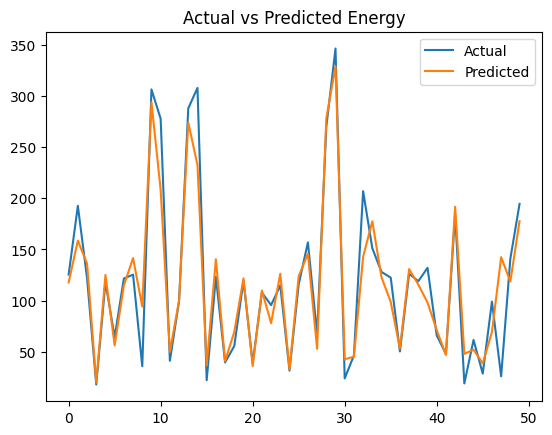

In [23]:
import matplotlib.pyplot as plt

preds = [predict_energy_svm(x) for x in X_test[:50]]

plt.plot(y_test[:50], label="Actual")
plt.plot(preds, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Energy")
plt.show()

In [24]:
def optimize_energy(pred_energy, temp, hour):
    suggestions = []

    # High energy consumption
    if pred_energy > 120:
        suggestions.append("Turn off unused appliances")
        suggestions.append("Shift heavy appliance usage to off-peak hours")

    # Moderate energy
    elif pred_energy > 90:
        suggestions.append("Monitor appliance usage to reduce consumption")

    # Temperature-based
    if temp > 35:
        suggestions.append("Reduce AC usage or increase temperature setting")

    # Peak hour condition
    if 18 <= hour <= 22:
        suggestions.append("Avoid using heavy appliances during peak hours")

    return suggestions

In [25]:

# FINAL ENERGY PREDICTION + OPTIMIZATION

def predict_energy_svm(input_data):
    input_scaled = scaler_X.transform([input_data])

    pred = svm.predict(input_scaled)

    pred = scaler_y.inverse_transform(pred.reshape(-1,1))
    return pred[0][0]



def optimize_energy(pred_energy, temp, hour):
    suggestions = []

    # High energy consumption
    if pred_energy > 120:
        suggestions.append("Turn off unused appliances")
        suggestions.append("Shift heavy appliance usage to off-peak hours")

    # Moderate energy consumption
    elif pred_energy > 90:
        suggestions.append("Monitor appliance usage to reduce consumption")

    # Temperature-based condition
    if temp > 35:
        suggestions.append("Reduce AC usage or increase temperature setting")

    # Peak hours condition
    if 18 <= hour <= 22:
        suggestions.append("Avoid using heavy appliances during peak hours")

    return suggestions


sample = X_test[0]   # real dataset sample


pred_energy = predict_energy_svm(sample)


temp_index = FEATURES.index('T2M')
hour_sin_index = FEATURES.index('hour_sin')

temp = sample[temp_index]

hour = 18


tips = optimize_energy(pred_energy, temp, hour)


print("\n ENERGY PREDICTION SYSTEM ")
print(f"Predicted Energy Consumption: {round(pred_energy,2)}")

print("\n OPTIMIZATION SUGGESTIONS ")
if tips:
    for t in tips:
        print("•", t)
else:
    print("Energy usage is optimal. No suggestions needed.")


 ENERGY PREDICTION SYSTEM 
Predicted Energy Consumption: 117.83

 OPTIMIZATION SUGGESTIONS 
• Monitor appliance usage to reduce consumption
• Avoid using heavy appliances during peak hours


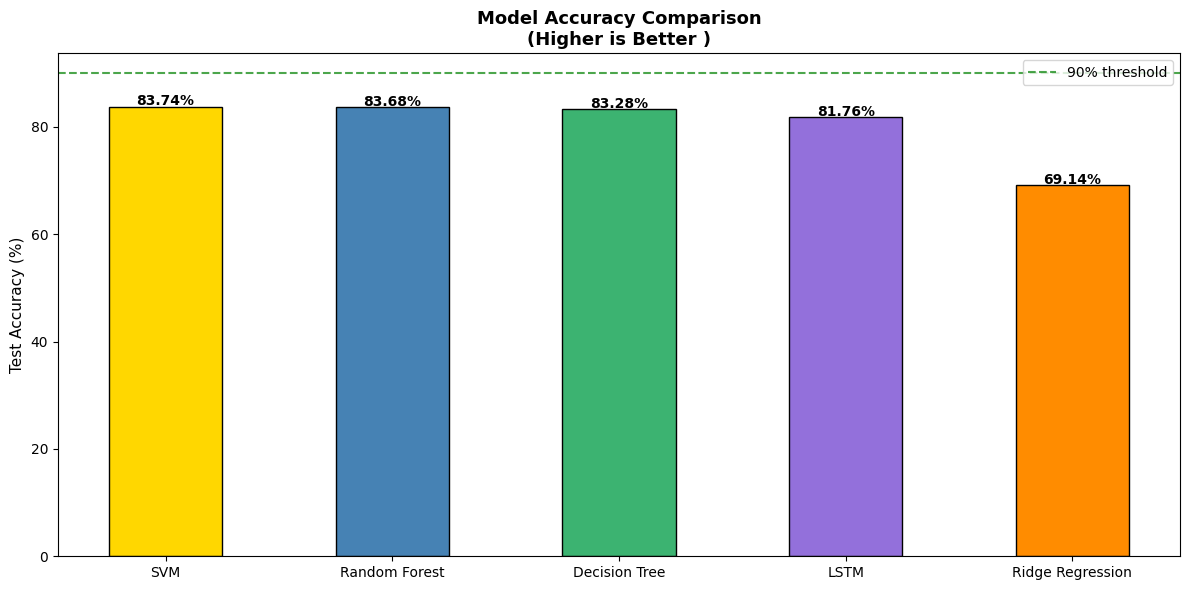

 Plot 1 saved — Model Accuracy


In [26]:

# PLOT 1 — Model Accuracy Comparison (%)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(model_names, acc_vals, color=model_colors, edgecolor='black', width=0.5)
for bar, v in zip(bars, acc_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(90, color='green', linestyle='--', lw=1.5, alpha=0.7, label='90% threshold')
ax.set_title('Model Accuracy Comparison\n(Higher is Better )', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_ylim(0, max(acc_vals) + 10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot1_model_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot 1 saved — Model Accuracy')

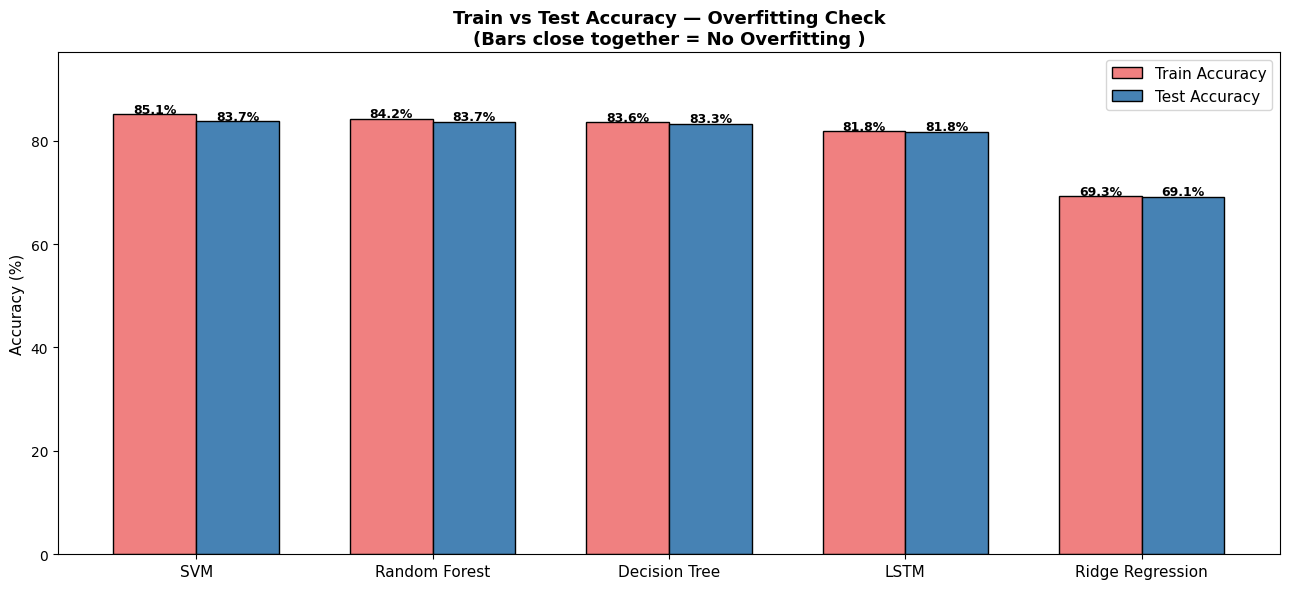

 Plot 2 saved — Train vs Test Accuracy


In [27]:

# PLOT 2 — Train vs Test Accuracy (Overfitting Check)

x = np.arange(len(model_names)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x-w/2, acc_tr_vals, w, label='Train Accuracy', color='lightcoral',  edgecolor='black')
b2 = ax.bar(x+w/2, acc_vals,    w, label='Test Accuracy',  color='steelblue',   edgecolor='black')
for b, v in zip(b1, acc_tr_vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
for b, v in zip(b2, acc_vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Train vs Test Accuracy — Overfitting Check\n(Bars close together = No Overfitting )', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11); ax.legend(fontsize=11)
ax.set_ylim(0, max(acc_tr_vals) + 12)
plt.tight_layout()
plt.savefig('plot2_train_vs_test_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot 2 saved — Train vs Test Accuracy')

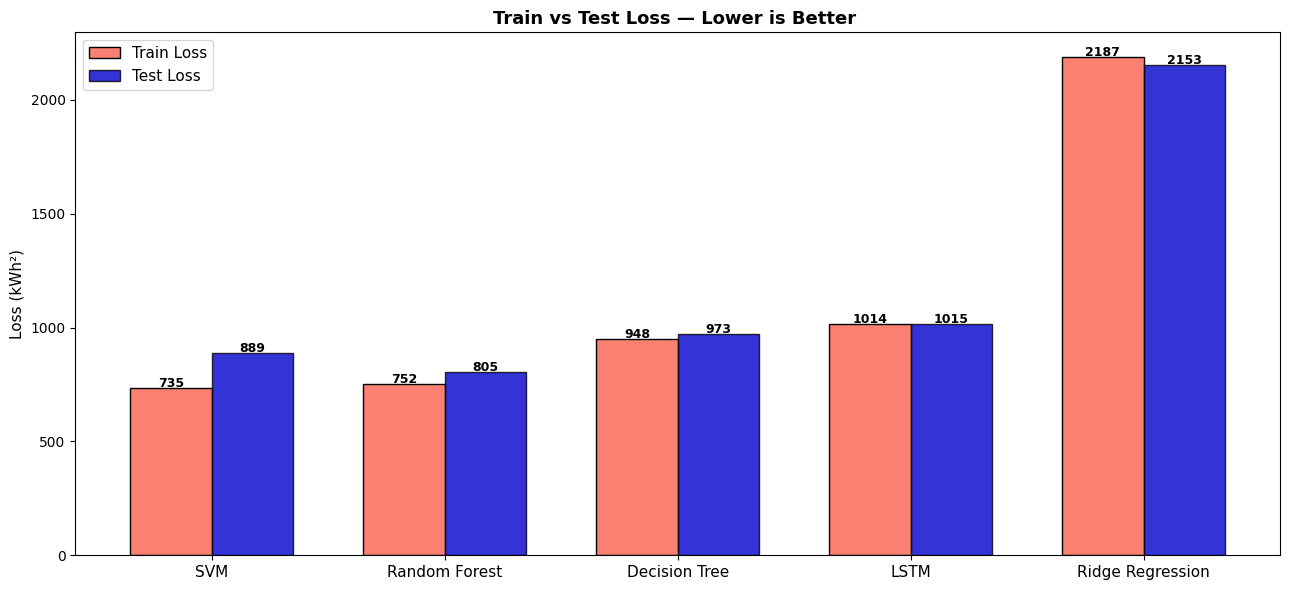

 Plot 3 saved — Train vs Test Loss


In [28]:

# PLOT 3 — Train vs Test Loss Comparison
x = np.arange(len(model_names)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x-w/2, tr_loss_vals, w, label='Train Loss', color='salmon',      edgecolor='black')
b2 = ax.bar(x+w/2, te_loss_vals, w, label='Test Loss',  color='mediumblue',  edgecolor='black', alpha=0.8)
for b, v in zip(b1, tr_loss_vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')
for b, v in zip(b2, te_loss_vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Train vs Test Loss — Lower is Better ', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Loss (kWh²)', fontsize=11); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot3_train_vs_test_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot 3 saved — Train vs Test Loss')

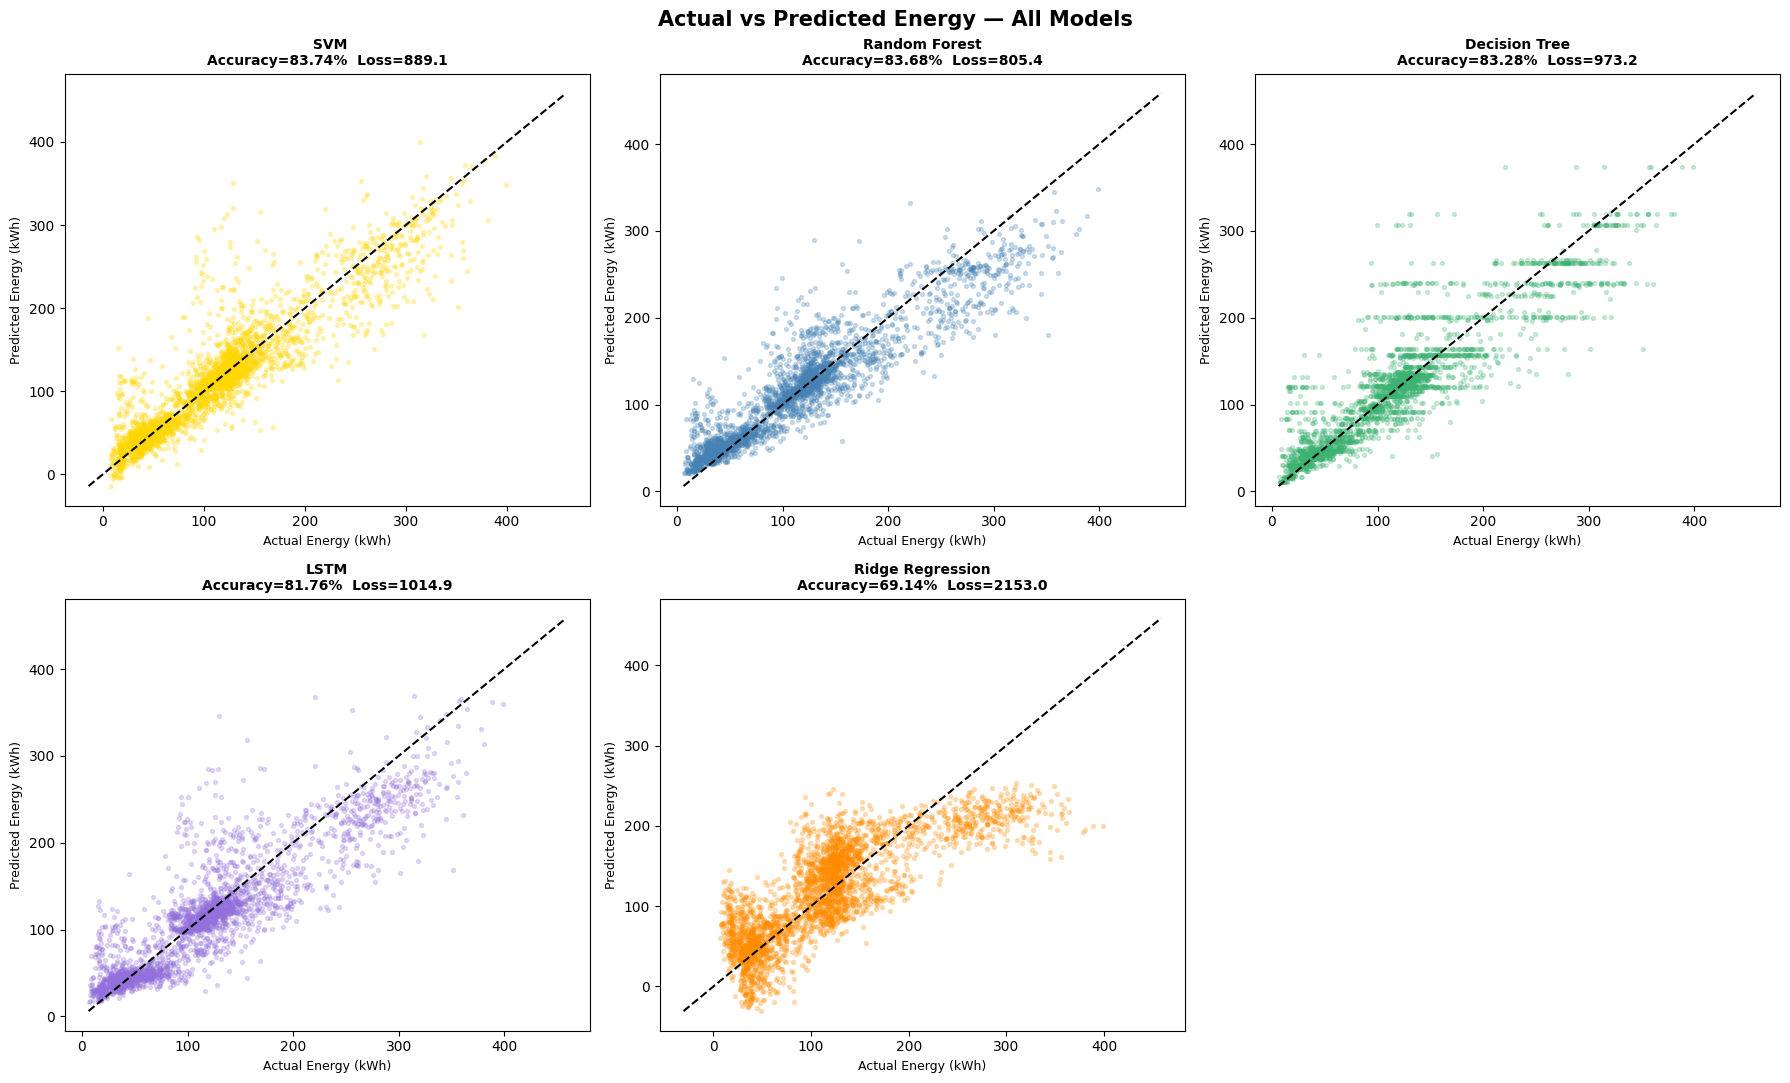

 Plot 4 saved — Actual vs Predicted


In [29]:

# PLOT 4 — Actual vs Predicted Energy (All 5 Models)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Actual vs Predicted Energy — All Models', fontsize=15, fontweight='bold')
axes = axes.flatten()
n   = min(3000, len(y_test))
idx = np.random.choice(len(y_test), n, replace=False)

for i, (name, res) in enumerate(sorted_models):
    ax = axes[i]
    ax.scatter(y_test[idx], res['pred'][idx], alpha=0.25, s=8, color=model_colors[i])
    lims = [min(y_test.min(), res['pred'].min()), max(y_test.max(), res['pred'].max())]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect Prediction')
    flag = ' ' if name == best_model_name else ''
    ax.set_title(f"{flag}{name}\nAccuracy={res['accuracy']:.2f}%  Loss={res['test_loss']:.1f}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual Energy (kWh)', fontsize=9)
    ax.set_ylabel('Predicted Energy (kWh)', fontsize=9)

axes[5].axis('off')
plt.tight_layout()
plt.savefig('plot4_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot 4 saved — Actual vs Predicted')

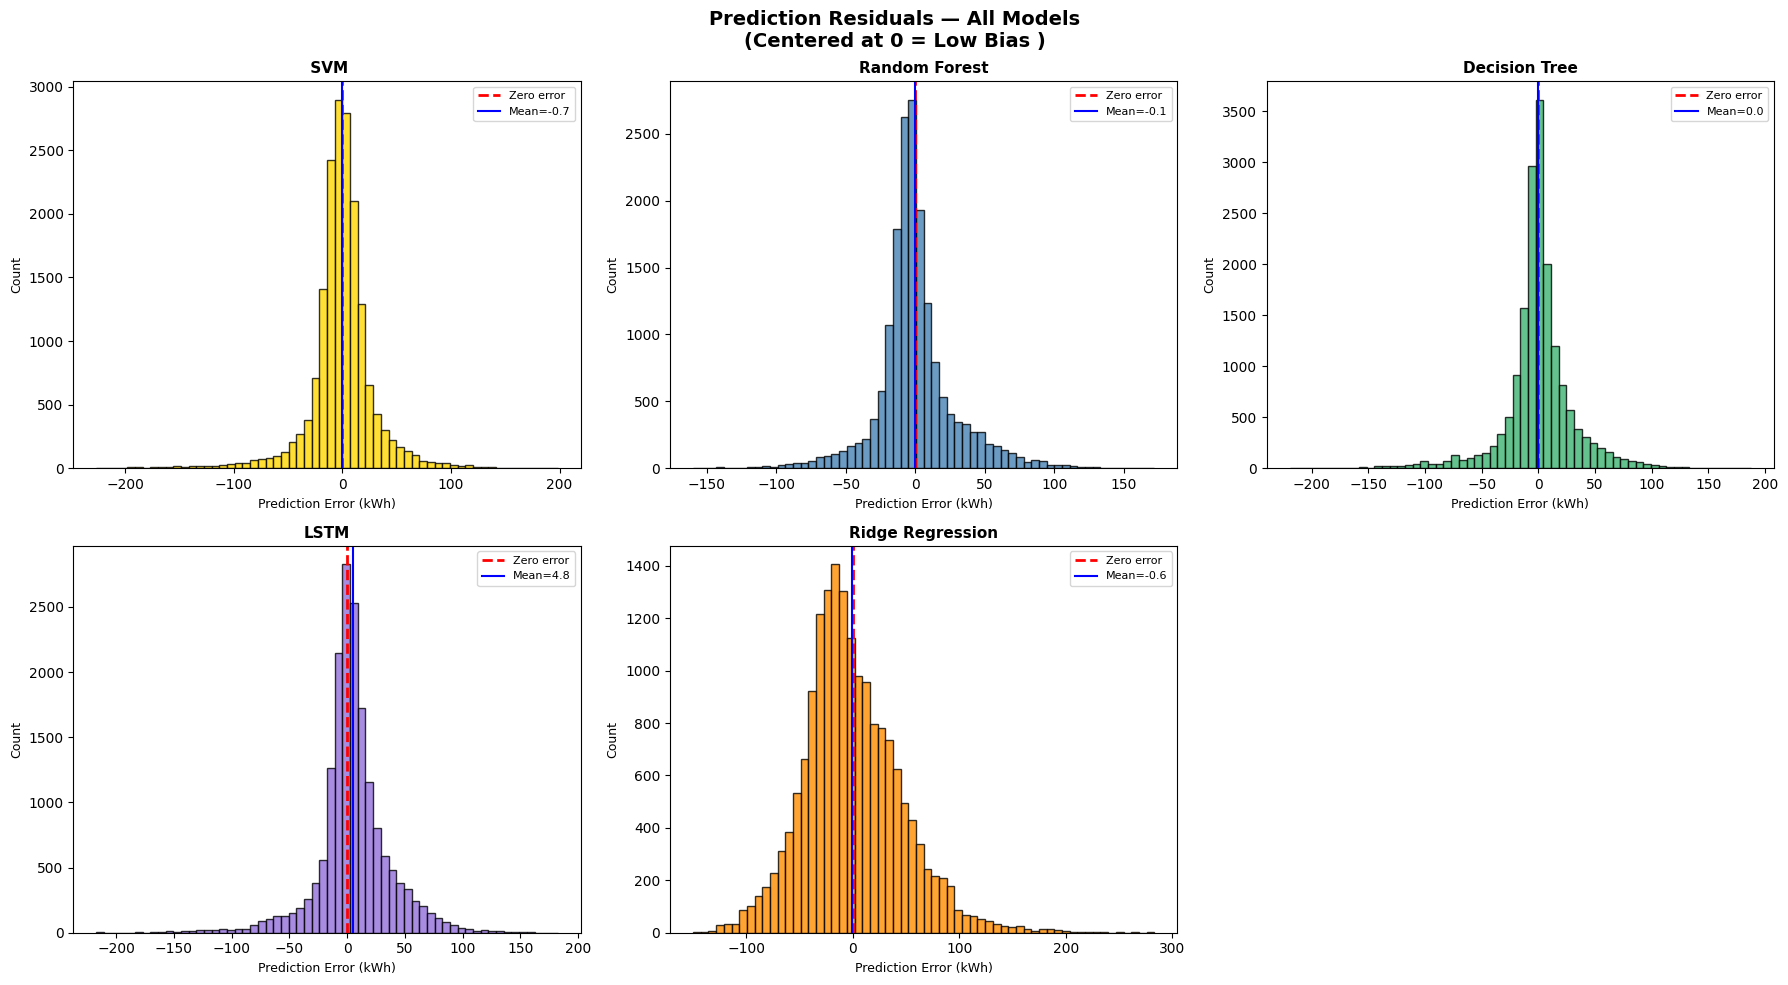

 Plot 5 saved — Prediction Error Distribution


In [30]:

# PLOT 5 — Prediction Residuals Distribution (All 5 Models)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Prediction Residuals — All Models\n(Centered at 0 = Low Bias )', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (name, res) in enumerate(sorted_models):
    ax = axes[i]
    resid = y_test - res['pred']
    ax.hist(resid, bins=60, color=model_colors[i], edgecolor='black', alpha=0.8)
    ax.axvline(0,            color='red',  linestyle='--', lw=2,  label='Zero error')
    ax.axvline(resid.mean(), color='blue', lw=1.5,                label=f'Mean={resid.mean():.1f}')
    flag = ' ' if name == best_model_name else ''
    ax.set_title(f'{flag}{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Prediction Error (kWh)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)

axes[5].axis('off')
plt.tight_layout()
plt.savefig('plot5_prediction_error_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot 5 saved — Prediction Error Distribution')

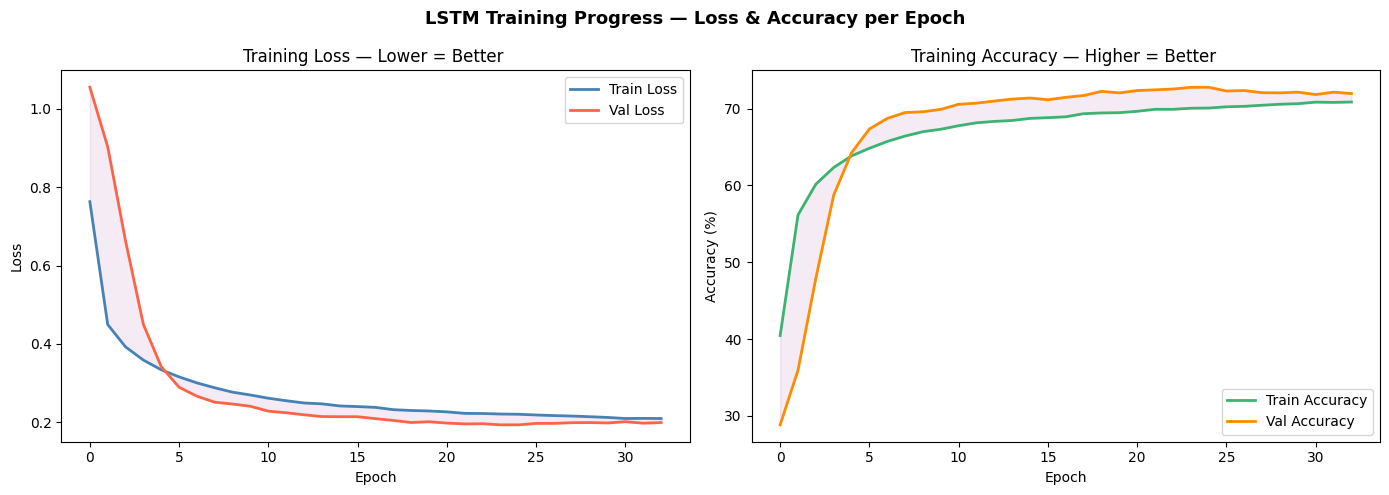

 Plot 6 saved — LSTM Training Progress


In [31]:

# PLOT 6 — LSTM Training Loss & Accuracy per Epoch

h = model_results['LSTM']['history']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training Progress — Loss & Accuracy per Epoch', fontsize=13, fontweight='bold')

axes[0].plot(h.history['loss'],     label='Train Loss', color='steelblue',     lw=2)
axes[0].plot(h.history['val_loss'], label='Val Loss',   color='tomato',        lw=2)
axes[0].fill_between(range(len(h.history['loss'])),
                     h.history['loss'], h.history['val_loss'], alpha=0.08, color='purple')
axes[0].set_title('Training Loss — Lower = Better ')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

# Convert MAE history to pseudo-accuracy for display
train_acc_hist = [max(0, (1 - v) * 100) for v in h.history['mae']]
val_acc_hist   = [max(0, (1 - v) * 100) for v in h.history['val_mae']]
axes[1].plot(train_acc_hist, label='Train Accuracy', color='mediumseagreen', lw=2)
axes[1].plot(val_acc_hist,   label='Val Accuracy',   color='darkorange',     lw=2)
axes[1].fill_between(range(len(train_acc_hist)),
                     train_acc_hist, val_acc_hist, alpha=0.08, color='purple')
axes[1].set_title('Training Accuracy — Higher = Better ')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend()

plt.tight_layout()
plt.savefig('plot6_lstm_training_progress.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot 6 saved — LSTM Training Progress')

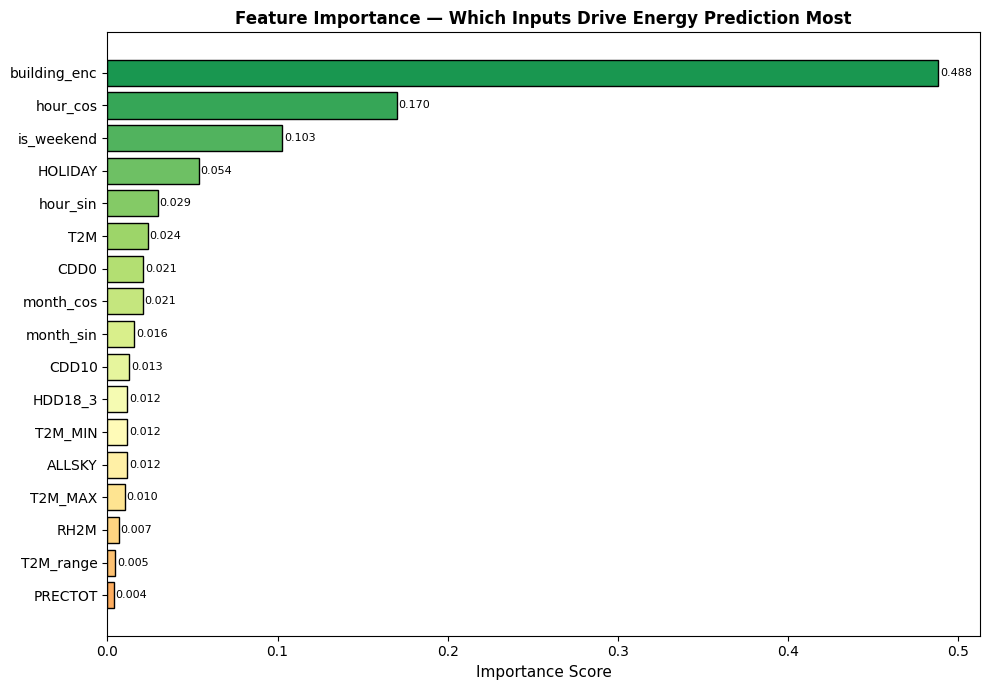

 Plot 7 saved — Feature Importance


In [32]:

# PLOT 7 — Feature Importance (Random Forest)
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi_df)))
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors, edgecolor='black')
ax.set_title('Feature Importance — Which Inputs Drive Energy Prediction Most',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
for i, val in enumerate(fi_df['Importance']):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('plot7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot 7 saved — Feature Importance')

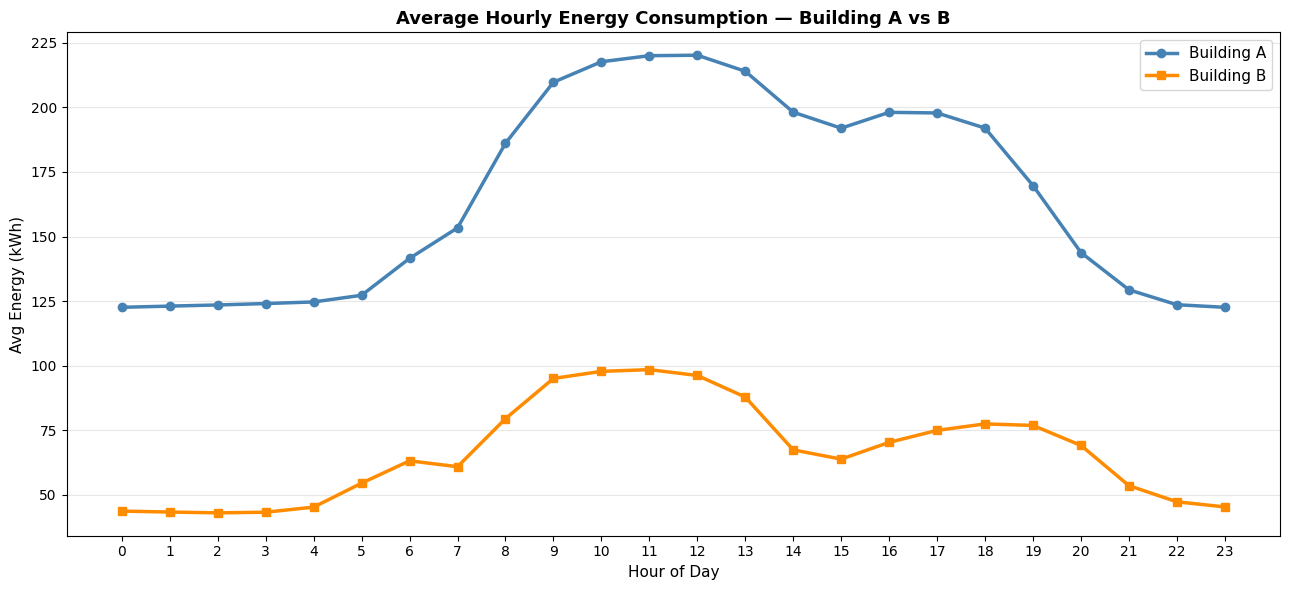

 Plot 8 saved — Hourly Energy Pattern


In [33]:

# PLOT 8 — Average Hourly Energy Consumption by Building
df_plot         = df_raw.copy()
df_plot['hour'] = pd.to_datetime(df_plot['DATE']).dt.hour
hourly          = df_plot.groupby(['hour','building'])['ENERGY'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))
for bld, color, marker in [('A','steelblue','o'), ('B','darkorange','s')]:
    sub = hourly[hourly['building'] == bld]
    ax.plot(sub['hour'], sub['ENERGY'], color=color, marker=marker,
            lw=2.5, markersize=6, label=f'Building {bld}')

ax.set_title('Average Hourly Energy Consumption — Building A vs B',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Avg Energy (kWh)', fontsize=11)
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot8_hourly_energy_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot 8 saved — Hourly Energy Pattern')

In [36]:
# CELL — Save Model + Scalers

best_obj = model_results[best_model_name]['model']

import joblib
import os

# Save model
best_filename = 'best_model.pkl'
joblib.dump(best_obj, best_filename)

# Save scalers
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

print("Model and scalers saved successfully!")

Model and scalers saved successfully!


In [37]:
# CELL — Download Files

from google.colab import files as colab_files

print('\nDownloading files...\n')

# Download model
if os.path.exists(best_filename):
    colab_files.download(best_filename)
    print(f'{best_filename} downloaded successfully!')
else:
    print(f'File not found: {best_filename}')

# Download scaler_X
if os.path.exists('scaler_X.pkl'):
    colab_files.download('scaler_X.pkl')
    print('scaler_X.pkl downloaded successfully!')
else:
    print('File not found: scaler_X.pkl')

# Download scaler_y
if os.path.exists('scaler_y.pkl'):
    colab_files.download('scaler_y.pkl')
    print('scaler_y.pkl downloaded successfully!')
else:
    print('File not found: scaler_y.pkl')


# SUMMARY

print('\n' + '='*60)
print('COMPLETE!')
print('='*60)
print(f'Best Model     : {best_model_name}')
print(f'Test Accuracy  : {best_acc:.2f}%')
print(f'Train Loss     : {model_results[best_model_name]["train_loss"]:.2f} kWh²')
print(f'Test Loss      : {model_results[best_model_name]["test_loss"]:.2f} kWh²')
print(f'Accuracy Gap   : {model_results[best_model_name]["gap"]:.2f}%')
print(f'Status         : {model_results[best_model_name]["overfit_status"]}')
print('='*60)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

best_model.pkl downloaded successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

scaler_X.pkl downloaded successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

scaler_y.pkl downloaded successfully!

COMPLETE!
Best Model     : SVM
Test Accuracy  : 83.74%
Train Loss     : 734.74 kWh²
Test Loss      : 889.15 kWh²
Accuracy Gap   : 1.38%
Status         :  OK
